# Arrhenius kinetics from batch experiments: parameter estimation by multiple shooting

A consecutive reaction $A \xrightarrow{k_1} B \xrightarrow{k_2} C$ runs in a batch reactor, once at
each of four temperatures. The rate constants follow Arrhenius' law around a reference temperature
$T_\mathrm{ref}$,

$$
k_i(T) = \exp\!\Big(\ln k_{i,\mathrm{ref}} - \frac{E_i}{R}\Big(\frac1T - \frac1{T_\mathrm{ref}}\Big)\Big),
\qquad \dot c_A = -k_1 c_A,\quad \dot c_B = k_1 c_A - k_2 c_B,\quad \dot c_C = k_2 c_B .
$$

Only $B$ and $C$ are measured, with noise, every four minutes. We estimate the four parameters
$\theta = (\ln k_{1,\mathrm{ref}}, \ln k_{2,\mathrm{ref}}, E_1/R, E_2/R)$ from all four experiments at once.

**Multiple shooting** makes the states at every sampling time decision variables as well. It then
asks the model to connect consecutive ones:

$$
\min_{s,\theta}\ \tfrac12 \sum_{e,m} \big\| (y_{e,m} - H s_{e,m}) / \sigma \big\|^2
\quad\text{s.t.}\quad s_{e,m+1} = \Phi(s_{e,m}; \theta, T_e),\qquad s_{e,0} = c_{e,0},
$$

where $\Phi$ is four RK4 steps over one sampling interval. The states can start from the data
rather than from a simulation with a poor $\theta$. This is the classic advantage of the method
(Bock, 1983). The price is a larger NLP, whose structure Scaly keeps:

- **One interval, written once.** `interval` is `vmap`ped over the intervals of an experiment. That
  function is in turn `vmap`ped over the experiments, with $\theta$ broadcast (stride 0) and the
  temperature sliced per experiment.
- **An arrowhead Lagrangian Hessian.** Every state block couples only to its neighbours and to
  $\theta$. Scaly finds this pattern and hands IPOPT its compact values.
- **The data are a parameter.** The generated solver is specialized to the experimental design,
  not to one data set.

| Scaly feature | Where |
| --- | --- |
| nested `sc.vmap` with a stride-0 (broadcast) input | defects over experiments × intervals |
| `sc.problem` with a parameter tree, `sc.solver(..., "ipopt")` | the estimation NLP, exact sparse Hessian |
| `sc.scan`, `sc.jacobian` through it | single-shooting sensitivities for the parameter covariance |

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
from scipy import integrate, optimize

import plotstyle
import scaly as sc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "kinetics_estimation"
rng = np.random.default_rng(7)

## Experiments and data

Four isothermal runs of 60 minutes at 320, 335, 350 and 365 K, with different initial
concentrations of $A$. The samples are taken every $\Delta t = 4$ min, so each run has $M = 15$
intervals. The noise is $\sigma = 0.01$ mol/L.

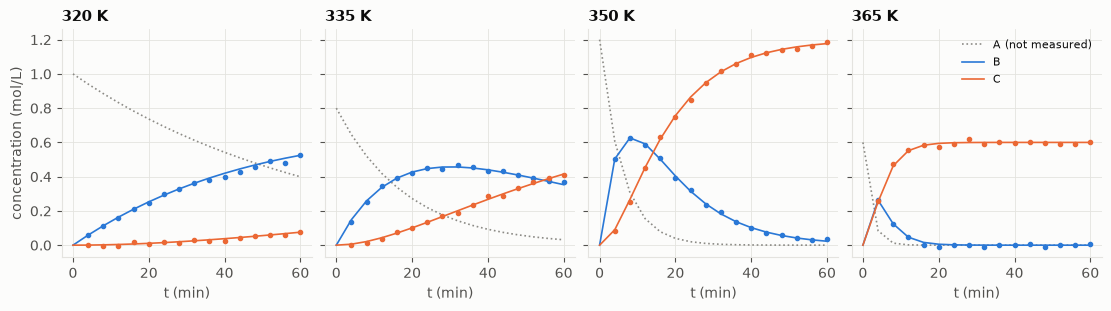

In [2]:
T_EXP = np.array([320.0, 335.0, 350.0, 365.0])
CA0 = np.array([1.0, 0.8, 1.2, 0.6])
N_EXP, M, DT, SUBSTEPS = len(T_EXP), 15, 4.0, 4
T_REF, SIGMA = 340.0, 0.01
THETA_TRUE = np.array([np.log(0.08), np.log(0.03), 0.9, 1.1])  # ln k_ref [1/min], E/R [1e4 K]
N_NODE = N_EXP * (M + 1)


def rates_np(theta, temp):
  return np.exp(theta[:2] - 1e4 * theta[2:] * (1.0 / temp - 1.0 / T_REF))


def rhs_np(c, k):
  return np.array([-k[0] * c[0], k[0] * c[0] - k[1] * c[1], k[1] * c[1]])


def simulate_np(theta, temp, ca0):
  """Exact solution by a tight ODE solve; this is the reference model, not the RK4 one."""
  k = rates_np(theta, temp)
  sol = integrate.solve_ivp(lambda t, c: rhs_np(c, k), (0, M * DT), [ca0, 0, 0], t_eval=DT * np.arange(M + 1), rtol=1e-11, atol=1e-13)
  return sol.y.T  # (M + 1, 3)


C_TRUE = np.array([simulate_np(THETA_TRUE, T, a) for T, a in zip(T_EXP, CA0)])
Y = C_TRUE[:, 1:, 1:] + SIGMA * rng.standard_normal((N_EXP, M, 2))  # B and C at t = 4, ..., 60 min

fig, axes = plt.subplots(1, N_EXP, figsize=(11, 3), sharey=True)
t = DT * np.arange(M + 1)
for e, ax in enumerate(axes):
  for s_, color, name in ((0, plotstyle.NEUTRAL, "A (not measured)"), (1, plotstyle.BLUE, "B"), (2, plotstyle.ORANGE, "C")):
    ax.plot(t, C_TRUE[e, :, s_], color=color, lw=1.2, ls=":" if s_ == 0 else "-", label=name)
    if s_:
      ax.plot(t[1:], Y[e, :, s_ - 1], "o", ms=3, color=color)
  ax.set_title(f"{T_EXP[e]:.0f} K")
  ax.set_xlabel("t (min)")
axes[0].set_ylabel("concentration (mol/L)")
axes[-1].legend(fontsize=8)
plt.show()

## One interval, then all of them

`interval` integrates one sampling interval with four RK4 steps. `experiment_defects` maps it over
the $M$ intervals of one run. The node states are read with stride 3, and the next node starts 3
further on. $\theta$ and the run's temperature are broadcast. `all_defects` maps that over the runs,
with each run's block of $3(M+1)$ node states and its temperature. Two nested `vmap`s give two
nested C loops.

In [3]:
@sc.function(sc.G(sc.L("s", 3), sc.L("theta", 4), sc.L("T", 1)), output=sc.L("s_end", ...))
def interval(inputs):
  c, theta, temp = inputs
  k = (theta[:2] - 1e4 * theta[2:] * (1.0 / temp[0] - 1.0 / T_REF)).exp()

  def f(c):
    r1, r2 = k[0] * c[0], k[1] * c[1]
    return sc.stack([-r1, r1 - r2, r2])

  h = DT / SUBSTEPS
  for _ in range(SUBSTEPS):
    k1 = f(c)
    k2 = f(c + 0.5 * h * k1)
    k3 = f(c + 0.5 * h * k2)
    k4 = f(c + h * k3)
    c = c + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
  return c


@sc.function(sc.G(sc.L("s_e", 3 * (M + 1)), sc.L("theta", 4), sc.L("T", 1)), output=sc.L("defects", ...))
def experiment_defects(inputs):
  s_e, theta, temp = inputs
  return sc.vmap(interval, M, [(s_e, 0, 3), (theta, 0, 0), (temp, 0, 0)]) - s_e[3:]


def all_defects(s, theta):
  return sc.vmap(experiment_defects, N_EXP, [(s, 0, 3 * (M + 1)), (theta, 0, 0), (sc.const(T_EXP), 0, 1)])


# which entries of the node vector are measured: B and C at nodes 1..M of every run
MEASURED = np.array([3 * (e * (M + 1) + m) + j for e in range(N_EXP) for m in range(1, M + 1) for j in (1, 2)])
INITIAL = np.array([3 * e * (M + 1) + j for e in range(N_EXP) for j in range(3)])
C0 = np.array([[a, 0.0, 0.0] for a in CA0]).ravel()


@sc.problem(vars=sc.G(sc.L("s", 3 * N_NODE), sc.L("theta", 4)), params=sc.L("y", Y.size))
def estimation(variables, y):
  s, theta = variables
  misfit = (y - sc.gather(s, MEASURED)) / SIGMA
  return sc.ProblemSpec(minimize=0.5 * sc.sumsqr(misfit), eq=(sc.gather(s, INITIAL) - sc.const(C0), all_defects(s, theta)))


print(f"{3 * N_NODE + 4} variables, {estimation.n_eq} equality constraints, {Y.size} measurements")

196 variables, 192 equality constraints, 120 measurements


## The structure IPOPT sees

The Lagrangian $L = f + \lambda^\top g$ has a Hessian that is block diagonal in the node states,
with one $3 \times 3$ block per node. Its last four rows and columns are dense, because every
interval depends on $\theta$. The constraint Jacobian is block bidiagonal, with a dense
$\theta$ column. Both patterns come out of the graph. The Hessian is coloured with a handful of
forward sweeps, independently of $M$ and the number of runs.

Hessian: 856 nonzeros of 38416, 5 colours; Jacobian: 1152 nonzeros


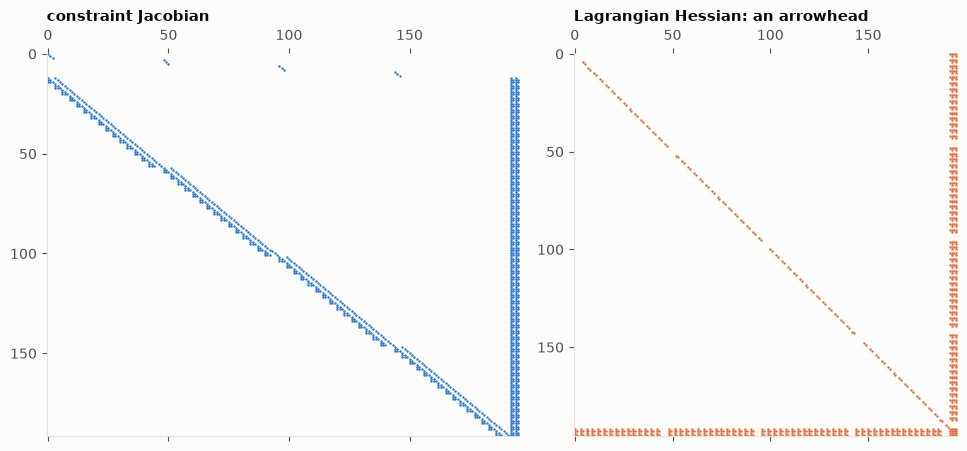

In [4]:
s_sym, th_sym = sc.sym("s", 3 * N_NODE), sc.sym("theta", 4)
w = sc.concat([s_sym, th_sym])
lam = sc.sym("lam", estimation.n_eq)
y_sym = sc.sym("y", Y.size)
g = sc.concat([sc.gather(w, INITIAL) - sc.const(C0), all_defects(w[: 3 * N_NODE], w[3 * N_NODE :])])
lagrangian = 0.5 * sc.sumsqr((y_sym - sc.gather(w, MEASURED)) / SIGMA) + (lam * g).sum()
hess_pattern = sc.sparse_hessian(lagrangian, w, triangle="full").sparsity
jac_pattern = sc.jacobian_sparsity(g, w)
colors = sc.star_coloring(hess_pattern)
print(f"Hessian: {hess_pattern.nnz} nonzeros of {w.shape[0] ** 2}, {max(colors) + 1} colours; Jacobian: {jac_pattern.nnz} nonzeros")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
axes[0].spy(jac_pattern.to_mask(), markersize=0.7, aspect="auto", color=plotstyle.BLUE)
axes[0].set_title("constraint Jacobian")
axes[1].spy(hess_pattern.to_mask(), markersize=0.7, color=plotstyle.ORANGE)
axes[1].set_title("Lagrangian Hessian: an arrowhead")
for ax in axes:
  ax.grid(False)
plt.show()

## Solve

The node states start from the data. $B$ and $C$ are measured, and $A$ follows from the mass
balance $c_A = c_{A,0} - c_B - c_C$. The parameters start far from the truth: both rate constants
are off by a factor of four and both activation energies by 40%.

In [5]:
solve = sc.solver(estimation, "ipopt", name="kinetics_ms", options={"tol": 1e-10})

THETA_START = np.array([np.log(0.02), np.log(0.12), 0.55, 1.55])
nodes0 = np.zeros((N_EXP, M + 1, 3))
nodes0[:, 1:, 1:] = Y
nodes0[:, 0, 0] = CA0
nodes0[:, 1:, 0] = CA0[:, None] - Y.sum(axis=2)
s_start = nodes0.ravel()


def estimate(y, s0, theta0):
  (s_hat, theta_hat), *_ = solve((s0, theta0), (np.zeros_like(s0), np.zeros(4)), np.zeros(estimation.n_eq), np.zeros(0), y.ravel())
  return s_hat, theta_hat


start = time.perf_counter()
s_hat, theta_hat = estimate(Y, s_start, THETA_START)
first = time.perf_counter() - start
stats = solve.solver_stats()
start = time.perf_counter()
estimate(Y, s_start, THETA_START)
again = time.perf_counter() - start
print(f"IPOPT: {stats.to_solver_status().name} in {stats.iter} iterations, {1e3 * again:.1f} ms (first call, with compilation: {first:.1f} s)")
names = ["ln k1,ref", "ln k2,ref", "E1/R [1e4 K]", "E2/R [1e4 K]"]
LABELS = [r"$\ln k_{1,\mathrm{ref}}$", r"$\ln k_{2,\mathrm{ref}}$", r"$E_1/R$ ($10^4$ K)", r"$E_2/R$ ($10^4$ K)"]
for n, a, b, c in zip(names, THETA_START, theta_hat, THETA_TRUE):
  print(f"  {n:13s} start {a:7.3f}   estimate {b:7.4f}   truth {c:7.4f}")

IPOPT: OK in 16 iterations, 17.4 ms (first call, with compilation: 2.8 s)
  ln k1,ref     start  -3.912   estimate -2.5319   truth -2.5257
  ln k2,ref     start  -2.120   estimate -3.5109   truth -3.5066
  E1/R [1e4 K]  start   0.550   estimate  0.9119   truth  0.9000
  E2/R [1e4 K]  start   1.550   estimate  1.1029   truth  1.1000


### The single-shooting comparison

Single shooting eliminates the states: it simulates each run from its initial condition with the
current $\theta$ and fits only $\theta$. Here it is SciPy's `least_squares` with a tight
`solve_ivp` inside, from the same start. On this well-behaved model both reach the same estimate.
The difference shows on unstable or oscillatory models, where a poor $\theta$ makes the simulation
run away from the data (or blow up) and single shooting stalls. Multiple shooting never
simulates far from the data, because the defects are only driven to zero as it converges.

In [6]:
def ss_residual(theta):
  return np.concatenate([(Y[e] - simulate_np(theta, T, a)[1:, 1:]).ravel() / SIGMA for e, (T, a) in enumerate(zip(T_EXP, CA0))])


path = []
start = time.perf_counter()
ss = optimize.least_squares(lambda th: (path.append(th.copy()), ss_residual(th))[1], THETA_START, xtol=1e-12, ftol=1e-12, gtol=1e-12)
t_ss = time.perf_counter() - start
print(f"single shooting (SciPy): success {ss.success}, {ss.nfev} simulations of all runs, {t_ss:.1f} s, cost {ss.cost:.4f}")
print(f"multiple shooting (IPOPT): cost {stats.obj:.4f}; |theta_ms - theta_ss|_inf = {np.abs(theta_hat - ss.x).max():.1e}")
print("  (the multiple-shooting model is RK4 with 1-minute steps, the single-shooting one a tight ODE solve;")
print("   their difference is the discretization error, far below the statistical uncertainty computed next)")

single shooting (SciPy): success True, 14 simulations of all runs, 3.6 s, cost 41.6641
multiple shooting (IPOPT): cost 41.6547; |theta_ms - theta_ss|_inf = 8.6e-05
  (the multiple-shooting model is RK4 with 1-minute steps, the single-shooting one a tight ODE solve;
   their difference is the discretization error, far below the statistical uncertainty computed next)


## How well are the parameters determined?

With the residuals $r(\theta)$ of the single-shooting model, the Gauss–Newton covariance is
$\operatorname{Cov}(\hat\theta) \approx (J^\top J)^{-1}$, where $J = \partial r/\partial\theta$. Scaly gives
$J$ by differentiating through an RK4 `scan` of each run. That is the same model as above, rolled
out, and the `scan` itself is `vmap`ped over the runs.

In [7]:
@sc.function(sc.G(sc.L("c", 3), sc.L("theta", 4), sc.L("T", 1)), output=sc.G(sc.L("c_next", ...), sc.L("out", ...)))
def sample_step(inputs):
  c, theta, temp = inputs
  c_next = interval((c, theta, temp))
  return c_next, c_next[1:]


@sc.function(sc.G(sc.L("c0", 3), sc.L("theta", 4), sc.L("T", 1)), output=sc.L("outputs", ...))
def run(inputs):
  c0, theta, temp = inputs
  _, outs = sc.scan(sample_step, c0, [(theta, 0, 0), (temp, 0, 0)], length=M)
  return outs.reshape((2 * M,))


@sc.function(sc.L("theta", 4), output=sc.L("predictions", ...))
def predict(theta):
  return sc.vmap(run, N_EXP, [(sc.const(C0), 0, 3), (theta, 0, 0), (sc.const(T_EXP), 0, 1)])


sensitivity = sc.jacobian(predict, "predictions", "theta")
J = sensitivity(theta_hat) / SIGMA
cov = np.linalg.inv(J.T @ J)
std = np.sqrt(np.diag(cov))
corr = cov / np.outer(std, std)
print("prediction check against the NLP's node states:", f"{np.abs(predict(theta_hat) - s_hat[MEASURED]).max():.1e}")
for n, a, b, c in zip(names, theta_hat, std, THETA_TRUE):
  print(f"  {n:13s} {a:7.4f} ± {b:.4f}   (truth {c:.4f}, {abs(a - c) / b:.1f} std away)")
print("correlation of ln k_ref with E/R: reaction 1 %.2f, reaction 2 %.2f" % (corr[0, 2], corr[1, 3]))

prediction check against the NLP's node states: 6.7e-16
  ln k1,ref     -2.5319 ± 0.0098   (truth -2.5257, 0.6 std away)
  ln k2,ref     -3.5109 ± 0.0074   (truth -3.5066, 0.6 std away)
  E1/R [1e4 K]   0.9119 ± 0.0068   (truth 0.9000, 1.8 std away)
  E2/R [1e4 K]   1.1029 ± 0.0084   (truth 1.1000, 0.3 std away)
correlation of ln k_ref with E/R: reaction 1 0.64, reaction 2 -0.48


The correlations between each $\ln k_\mathrm{ref}$ and its $E/R$ are moderate, because
$T_\mathrm{ref}$ = 340 K lies inside the temperature range. The textbook parametrization
$k = A e^{-E/RT}$ is the limit $T_\mathrm{ref} \to \infty$, where $\ln A = \ln k_\mathrm{ref} + E/(R T_\mathrm{ref})$.
The same covariance, mapped linearly into $(\ln A, E/R)$, shows why that form is notoriously
ill-conditioned. A Monte Carlo over fresh data sets confirms the ellipses. Each data set is
estimated by the same compiled solver, warm-started from the truth.

correlation of ln A with E/R: reaction 1 0.9993, reaction 2 0.9997


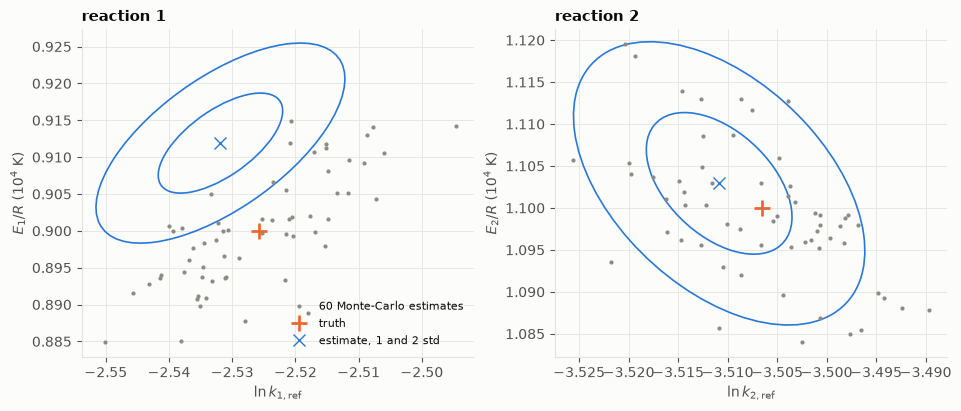

Monte-Carlo std / Gauss–Newton std: [1.17 1.09 1.12 0.95]


In [8]:
to_arrhenius = np.eye(4)
to_arrhenius[0, 2] = to_arrhenius[1, 3] = 1e4 / T_REF  # ln A = ln k_ref + (E/R) / T_ref
cov_a = to_arrhenius @ cov @ to_arrhenius.T
std_a = np.sqrt(np.diag(cov_a))
print("correlation of ln A with E/R: reaction 1 %.4f, reaction 2 %.4f" % (cov_a[0, 2] / std_a[0] / std_a[2], cov_a[1, 3] / std_a[1] / std_a[3]))

mc = []
for _ in range(60):
  y_mc = C_TRUE[:, 1:, 1:] + SIGMA * rng.standard_normal((N_EXP, M, 2))
  mc.append(estimate(y_mc, C_TRUE.ravel(), THETA_TRUE)[1])
mc = np.array(mc)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, (i, j) in zip(axes, ((0, 2), (1, 3))):
  ax.plot(mc[:, i], mc[:, j], ".", color=plotstyle.NEUTRAL, ms=4, label="60 Monte-Carlo estimates")
  vals, vecs = np.linalg.eigh(cov[np.ix_([i, j], [i, j])])
  for nsig in (1, 2):
    major, minor = 2 * nsig * np.sqrt(vals[1]), 2 * nsig * np.sqrt(vals[0])  # eigh sorts ascending
    ax.add_patch(
      Ellipse(theta_hat[[i, j]], major, minor, angle=np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1])), fill=False, color=plotstyle.BLUE, lw=1.2)
    )
  ax.plot(*THETA_TRUE[[i, j]], "+", color=plotstyle.ORANGE, ms=12, mew=2, label="truth")
  ax.plot(*theta_hat[[i, j]], "x", color=plotstyle.BLUE, ms=8, label="estimate, 1 and 2 std")
  ax.set_xlabel(LABELS[i])
  ax.set_ylabel(LABELS[j])
  ax.set_title(f"reaction {i + 1}")
axes[0].legend(fontsize=8)
plt.show()
print("Monte-Carlo std / Gauss–Newton std:", np.round(mc.std(axis=0) / std, 2))

## The generated C

The estimator is one C module with IPOPT's oracles: the objective, the defects with their
compact Jacobian and the compact Lagrangian Hessian. The model loops (four RK4 steps, $M$
intervals, the runs) are loops in C. The module links against the vendored IPOPT.

In [9]:
module = write_module(solve, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB")

kinetics_ms.c: 2701 lines, 165 kB
